# L1_T2 — Preprocessing: Face Detection, Crop & Lighting Normalization
### Layer 1 of the Aura pipeline · Task 2 of N · v2 (archive-based, matches L1_T1's storage fix)

**What this notebook does:** extracts the archives `L1_T1` produced, runs face detection / cropping /
lighting normalization on every image, and produces training-ready 224×224 crops — using the same
local-disk-first, archive-once, verify-before-trusting pattern `L1_T1` was rebuilt around, so this notebook
doesn't reintroduce the same Drive data-loss risk on its own output (which would otherwise mean writing
~101,000 individual preprocessed files directly to Drive — exactly the failure mode we just fixed).

**Two different strategies for two different kinds of images:**

| Dataset | What the images actually are | Strategy |
|---|---|---|
| FairFace | Guaranteed face photos (Flickr headshots) | Face detection → crop to face + margin → resize |
| Fitzpatrick17k | Dermatology-atlas photos of **skin conditions** — could be a face, an arm, a hand, a torso, anything | Try face detection first. **If no face is found, fall back to using the whole image** rather than discarding it |

**A caveat about the crop itself:** this uses MediaPipe's *face detection* (a bounding box), not the 468-point
face mesh with named forehead/cheek landmark indices — precise landmark-index sub-region cropping needs
numbers verified against real test images, not guessed at confidently. The bounding-box crop plus a full-face
resize is the standard approach used in most published Fitzpatrick-classification work.

**Before you run this:** `L1_T1_Data_Gathering` (v2) must have finished and verified successfully — this
notebook reads `manifest.json` and the two `.tar.gz` archives it produced.

## Step 0 — Mount Drive and locate L1_T1's archives

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json

DRIVE_ROOT = "/content/drive/MyDrive/Projects/Aura/Layer1_SkinTone"
MANIFEST_PATH = f"{DRIVE_ROOT}/manifest.json"

assert os.path.exists(MANIFEST_PATH), (
    "manifest.json not found at the expected path -- did L1_T1_Data_Gathering (v2) finish and verify "
    "successfully? Check Projects/Aura/Layer1_SkinTone/ on Drive directly if unsure."
)
with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

print(json.dumps(manifest, indent=2))

FAIRFACE_ARCHIVE = manifest["datasets"]["fairface"]["drive_archive"]
FITZ_ARCHIVE = manifest["datasets"]["fitzpatrick17k"]["drive_archive"]
FITZ_USABLE_COUNT = manifest["datasets"]["fitzpatrick17k"]["usable_image_count"]

assert os.path.exists(FAIRFACE_ARCHIVE), f"Archive listed in manifest but not found on Drive: {FAIRFACE_ARCHIVE}"
assert os.path.exists(FITZ_ARCHIVE), f"Archive listed in manifest but not found on Drive: {FITZ_ARCHIVE}"
print("\nBoth archives confirmed present on Drive.")


Mounted at /content/drive
{
  "layer": "01_skin_tone_color_classification",
  "task": "L1_T1_data_gathering",
  "version": "v2_archive_based",
  "generated_at_utc": "2026-09-27T00:24:32.378864+00:00",
  "storage_pattern": "Each dataset is stored on Drive as ONE .tar.gz archive, not individual files. This avoids the Google Drive FUSE-mount async-sync data loss that affected the v1 notebook. L1_T2 and later notebooks must extract these archives to local disk before use.",
  "datasets": {
    "fairface": {
      "drive_archive": "/content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/datasets/fairface/fairface.tar.gz",
      "archive_size_mb": 2964.1
    },
    "fitzpatrick17k": {
      "drive_archive": "/content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/datasets/fitzpatrick17k/fitzpatrick17k.tar.gz",
      "archive_size_mb": 233.1,
      "usable_image_count": 3734,
      "class_balance_note": "dermaamin.com is permanently offline (NXDOMAIN, confirmed manually) -- ~76% of the raw 16,577 U

## Step 0.5 — Set up local working directories and check disk space

In [ ]:
LOCAL_ROOT = "/content/aura_local/Layer1_SkinTone"
LOCAL_EXTRACTED = f"{LOCAL_ROOT}/extracted"
LOCAL_FAIRFACE_DIR = f"{LOCAL_EXTRACTED}/fairface"
LOCAL_FITZ_DIR = f"{LOCAL_EXTRACTED}/fitzpatrick17k"
LOCAL_FITZ_IMG_DIR = f"{LOCAL_FITZ_DIR}/images"

LOCAL_PREPROCESSED = f"{LOCAL_ROOT}/preprocessed"
LOCAL_PP_FAIRFACE = f"{LOCAL_PREPROCESSED}/fairface"
LOCAL_PP_FAIRFACE_TRAIN = f"{LOCAL_PP_FAIRFACE}/train"
LOCAL_PP_FAIRFACE_VAL = f"{LOCAL_PP_FAIRFACE}/validation"
LOCAL_PP_FITZ = f"{LOCAL_PREPROCESSED}/fitzpatrick17k"

for d in [LOCAL_EXTRACTED, LOCAL_PREPROCESSED, LOCAL_PP_FAIRFACE, LOCAL_PP_FAIRFACE_TRAIN,
          LOCAL_PP_FAIRFACE_VAL, LOCAL_PP_FITZ]:
    os.makedirs(d, exist_ok=True)

# Drive-side destination for the PREPROCESSED archives (new, doesn't exist from L1_T1)
DRIVE_PREPROCESSED = f"{DRIVE_ROOT}/preprocessed"
DRIVE_PP_FAIRFACE = f"{DRIVE_PREPROCESSED}/fairface"
DRIVE_PP_FITZ = f"{DRIVE_PREPROCESSED}/fitzpatrick17k"
for d in [DRIVE_PREPROCESSED, DRIVE_PP_FAIRFACE, DRIVE_PP_FITZ]:
    os.makedirs(d, exist_ok=True)

import shutil
local_total, local_used, local_free = shutil.disk_usage("/content")
print(f"Colab local disk — Free: {local_free/1e9:.1f} GB")
if local_free / 1e9 < 15:
    print("⚠️  Less than 15 GB free on local disk -- extraction + preprocessing needs headroom for both")
    print("   the extracted originals AND the preprocessed outputs at the same time.")
else:
    print("✅ Enough local disk headroom to proceed.")

drive_total, drive_used, drive_free = shutil.disk_usage("/content/drive/MyDrive")
print(f"Drive — Free: {drive_free/1e9:.1f} GB")


Colab local disk — Free: 70.0 GB
✅ Enough local disk headroom to proceed.
Drive — Free: 53.9 GB


## Step 1 — Install dependencies

**No version pin on `mediapipe` this time.** We initially tried pinning to an older version (`0.10.21`) to
keep using MediaPipe's legacy `mp.solutions.*` API, but this Colab runtime's Python version has no prebuilt
wheel for anything older than `0.10.30`, and `mp.solutions` was already removed by `0.10.31` (confirmed via a
MediaPipe GitHub issue). Version-pinning our way back to the old API is a dead end here. Step 3 below uses
MediaPipe's current, actively-supported **Tasks API** instead, which works with whatever version installs by
default.

In [ ]:
!pip install -q mediapipe opencv-python-headless pandas tqdm pillow
print("Dependencies installed (mediapipe: latest, using the Tasks API -- see Step 3).")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 14.8 MB/s eta 0:00:00
Dependencies installed (mediapipe: latest, using the Tasks API -- see Step 3).


## Step 2 — Copy both archives to local disk, then extract locally

**Copy first, extract second — deliberately two steps, not one.** Extracting directly from a Drive-mounted
path with `tarfile.extractall()` does a lot of seeking back and forth as it works through a multi-GB archive,
and that sustained random-access pattern over Drive's FUSE network mount is a known way to trigger
`OSError: [Errno 107] Transport endpoint is not connected` — the mount itself drops mid-operation. A plain
sequential file copy is a much gentler operation for the FUSE mount to handle; once the archive is sitting on
local disk, extraction is fast, local, and not subject to this failure mode at all.

In [ ]:
import shutil

LOCAL_ARCHIVES = "/content/aura_local/archives"
os.makedirs(LOCAL_ARCHIVES, exist_ok=True)

def copy_from_drive(drive_path, label):
    local_path = os.path.join(LOCAL_ARCHIVES, os.path.basename(drive_path))
    print(f"Copying {label} from Drive to local disk...")
    shutil.copy2(drive_path, local_path)
    drive_size = os.path.getsize(drive_path)
    local_size = os.path.getsize(local_path)
    assert local_size == drive_size, f"Copy size mismatch for {label}: drive={drive_size}, local={local_size}"
    print(f"  ✅ {label} copied ({local_size/1e6:.1f} MB) and verified.")
    return local_path

fairface_local_archive = copy_from_drive(FAIRFACE_ARCHIVE, "FairFace archive")
fitz_local_archive = copy_from_drive(FITZ_ARCHIVE, "Fitzpatrick17k archive")


Copying FairFace archive from Drive to local disk...
  ✅ FairFace archive copied (2964.1 MB) and verified.
Copying Fitzpatrick17k archive from Drive to local disk...
  ✅ Fitzpatrick17k archive copied (233.1 MB) and verified.


In [ ]:
import tarfile

print("Extracting FairFace archive (from local copy)...")
with tarfile.open(fairface_local_archive, "r:gz") as tar:
    tar.extractall(LOCAL_EXTRACTED, filter="data")  # filter="data": safe extraction, avoids the Python 3.14 deprecation warning

print("Extracting Fitzpatrick17k archive (from local copy)...")
with tarfile.open(fitz_local_archive, "r:gz") as tar:
    tar.extractall(LOCAL_EXTRACTED, filter="data")

print("Extraction complete.\n")

# Verify: count extracted files against expectations
ff_train_count = len([f for f in os.listdir(f"{LOCAL_FAIRFACE_DIR}/train") if f.endswith(".jpg")])
ff_val_count = len([f for f in os.listdir(f"{LOCAL_FAIRFACE_DIR}/validation") if f.endswith(".jpg")])
fitz_img_count = len([f for f in os.listdir(LOCAL_FITZ_IMG_DIR) if f.endswith(".jpg")])

print(f"FairFace train images extracted:      {ff_train_count} (expected 86,744)")
print(f"FairFace validation images extracted: {ff_val_count} (expected 10,954)")
print(f"Fitzpatrick17k images extracted:       {fitz_img_count}")

assert ff_train_count == 86744, f"FairFace train count mismatch: got {ff_train_count}"
assert ff_val_count == 10954, f"FairFace validation count mismatch: got {ff_val_count}"
print("\n✅ Extraction verified against expected counts.")


Extracting FairFace archive (from local copy)...
Extracting Fitzpatrick17k archive (from local copy)...
Extraction complete.

FairFace train images extracted:      86744 (expected 86,744)
FairFace validation images extracted: 10954 (expected 10,954)
Fitzpatrick17k images extracted:       3887

✅ Extraction verified against expected counts.


## Step 3 — Define the preprocessing function and the archive/upload/verify helper

Same preprocessing logic as the original design: MediaPipe face detection with a margin, fallback to the
full image when no face is found, resize to 224×224, then CLAHE lighting normalization on the L channel only
(LAB colorspace) so brightness/shadow gets corrected without distorting the actual tone information.

In [ ]:
import cv2
import numpy as np
import mediapipe as mp

mp_face_detection = mp.solutions.face_detection
_face_detector = mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5)

TARGET_SIZE = 224
MARGIN_RATIO = 0.25

def _apply_clahe_lightness(img_rgb):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)

def preprocess_image(img_rgb):
    """Returns (processed_image, face_detected: bool)."""
    h, w = img_rgb.shape[:2]
    results = _face_detector.process(img_rgb)

    face_detected = bool(results.detections)
    if face_detected:
        box = results.detections[0].location_data.relative_bounding_box
        x1 = max(0, int((box.xmin - box.width * MARGIN_RATIO) * w))
        y1 = max(0, int((box.ymin - box.height * MARGIN_RATIO) * h))
        x2 = min(w, int((box.xmin + box.width * (1 + MARGIN_RATIO)) * w))
        y2 = min(h, int((box.ymin + box.height * (1 + MARGIN_RATIO)) * h))
        if x2 > x1 and y2 > y1:
            crop = img_rgb[y1:y2, x1:x2]
        else:
            crop = img_rgb
            face_detected = False
    else:
        crop = img_rgb

    resized = cv2.resize(crop, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)
    normalized = _apply_clahe_lightness(resized)
    return normalized, face_detected


AttributeError: module 'mediapipe' has no attribute 'solutions'

In [ ]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
import urllib.request

# Tasks API needs a .tflite model file (the legacy mp.solutions API bundled it; the Tasks API doesn't).
FACE_MODEL_PATH = "/content/blaze_face_short_range.tflite"
FACE_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/face_detector/"
    "blaze_face_short_range/float16/1/blaze_face_short_range.tflite"
)
if not os.path.exists(FACE_MODEL_PATH):
    urllib.request.urlretrieve(FACE_MODEL_URL, FACE_MODEL_PATH)

_face_detector = vision.FaceDetector.create_from_options(
    vision.FaceDetectorOptions(
        base_options=mp_python.BaseOptions(model_asset_path=FACE_MODEL_PATH),
        min_detection_confidence=0.5,
    )
)

TARGET_SIZE = 224
MARGIN_RATIO = 0.25

def _apply_clahe_lightness(img_rgb):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)

def preprocess_image(img_rgb):
    """Returns (processed_image, face_detected: bool)."""
    h, w = img_rgb.shape[:2]
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(img_rgb))
    results = _face_detector.detect(mp_img)

    face_detected = bool(results.detections)
    if face_detected:
        # Highest-confidence detection; bounding_box is in PIXELS (origin_x, origin_y, width, height)
        det = max(results.detections, key=lambda d: d.categories[0].score)
        bb = det.bounding_box
        x1 = max(0, int(bb.origin_x - bb.width * MARGIN_RATIO))
        y1 = max(0, int(bb.origin_y - bb.height * MARGIN_RATIO))
        x2 = min(w, int(bb.origin_x + bb.width * (1 + MARGIN_RATIO)))
        y2 = min(h, int(bb.origin_y + bb.height * (1 + MARGIN_RATIO)))
        if x2 > x1 and y2 > y1:
            crop = img_rgb[y1:y2, x1:x2]
        else:
            crop = img_rgb
            face_detected = False
    else:
        crop = img_rgb

    resized = cv2.resize(crop, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)
    normalized = _apply_clahe_lightness(resized)
    return normalized, face_detected

In [ ]:
import time

def archive_and_upload(local_dir, archive_filename, drive_dest_dir, arcname=None):
    """Same pattern as L1_T1: tar locally, copy the ONE archive to Drive, verify by size."""
    local_archive_path = os.path.join("/content/aura_local", archive_filename)
    arcname = arcname or os.path.basename(local_dir.rstrip("/"))

    print(f"Archiving {local_dir} ...")
    with tarfile.open(local_archive_path, "w:gz") as tar:
        tar.add(local_dir, arcname=arcname)
    local_size = os.path.getsize(local_archive_path)
    print(f"  Local archive: {local_archive_path} ({local_size/1e6:.1f} MB)")

    drive_archive_path = os.path.join(drive_dest_dir, archive_filename)
    print(f"Copying to Drive: {drive_archive_path} ...")
    shutil.copy2(local_archive_path, drive_archive_path)

    time.sleep(2)
    drive_size = os.path.getsize(drive_archive_path)
    if drive_size != local_size:
        raise RuntimeError(
            f"SIZE MISMATCH after copying {archive_filename}: local={local_size}, drive={drive_size}. "
            "Do not trust this file yet -- re-run this cell."
        )
    print(f"  ✅ Verified on Drive: {drive_size/1e6:.1f} MB matches local exactly.")
    return drive_archive_path, drive_size


## Step 4 — Visual QA on a handful of samples BEFORE running at scale

Look at the actual output before committing to a 45-90 minute run across 97,698+ images. If crops look wrong
or lighting normalization looks too aggressive, adjust `MARGIN_RATIO` or `clipLimit` in Step 3 and re-run
this cell before proceeding.

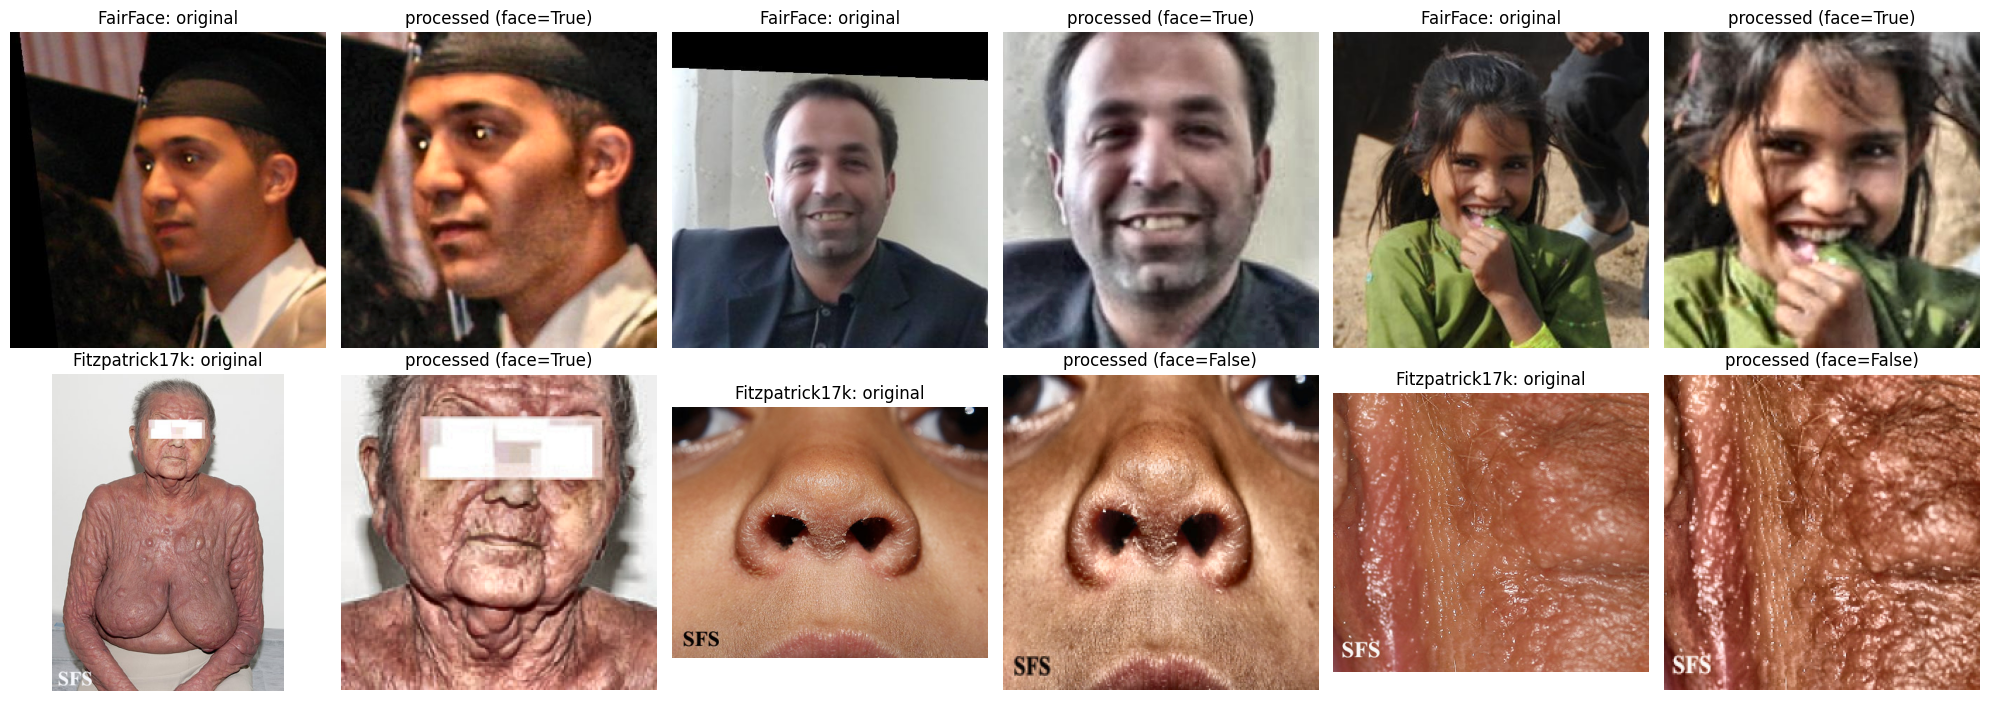

FairFace should show face=True almost always. Fitzpatrick17k will show a genuine mix -- both
face=True and face=False are expected outcomes there, not errors.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

def load_rgb(path):
    return np.array(Image.open(path).convert("RGB"))

fairface_train_labels = pd.read_csv(f"{LOCAL_FAIRFACE_DIR}/train_labels.csv")
fitz_usable = pd.read_csv(f"{LOCAL_FITZ_DIR}/fitzpatrick17k_usable.csv")

sample_fairface = fairface_train_labels.sample(min(3, len(fairface_train_labels)), random_state=42)
sample_fitz = fitz_usable.sample(min(3, len(fitz_usable)), random_state=42)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for i, (_, row) in enumerate(sample_fairface.iterrows()):
    path = os.path.join(LOCAL_FAIRFACE_DIR, "train", row["filename"])
    orig = load_rgb(path)
    processed, face_found = preprocess_image(orig)
    axes[0, i*2].imshow(orig); axes[0, i*2].set_title("FairFace: original"); axes[0, i*2].axis("off")
    axes[0, i*2+1].imshow(processed); axes[0, i*2+1].set_title(f"processed (face={face_found})"); axes[0, i*2+1].axis("off")

for i, (_, row) in enumerate(sample_fitz.iterrows()):
    # image_filename is relative -- resolve against the LOCAL extracted images dir
    path = os.path.join(LOCAL_FITZ_IMG_DIR, row["image_filename"])
    orig = load_rgb(path)
    processed, face_found = preprocess_image(orig)
    axes[1, i*2].imshow(orig); axes[1, i*2].set_title("Fitzpatrick17k: original"); axes[1, i*2].axis("off")
    axes[1, i*2+1].imshow(processed); axes[1, i*2+1].set_title(f"processed (face={face_found})"); axes[1, i*2+1].axis("off")

plt.tight_layout()
plt.show()

print("FairFace should show face=True almost always. Fitzpatrick17k will show a genuine mix -- both")
print("face=True and face=False are expected outcomes there, not errors.")


## Step 5 — Process FairFace at scale (to LOCAL disk)

Writes to local disk, not Drive -- Drive only sees this once it's archived in Step 7. Resume-safe within
this session (skips already-processed files), though a fresh session means re-extracting from the archive
first (Step 2), which is fast, then this can resume from wherever local disk got to.

In [ ]:
from tqdm.auto import tqdm

def process_fairface_split(split_name, labels_csv_path, src_dir, out_dir):
    labels_df = pd.read_csv(labels_csv_path)
    out_records = []
    error_count = 0

    for _, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc=f"Preprocessing FairFace/{split_name}"):
        fname = row["filename"]
        out_path = os.path.join(out_dir, fname)
        if os.path.exists(out_path):
            out_records.append({**row.to_dict(), "processed_filename": fname})
            continue
        try:
            orig = load_rgb(os.path.join(src_dir, fname))
            processed, face_found = preprocess_image(orig)
            Image.fromarray(processed).save(out_path, "JPEG", quality=92)
            out_records.append({**row.to_dict(), "processed_filename": fname})
        except Exception as e:
            error_count += 1
            print(f"  Skipped {fname}: {type(e).__name__}: {e}")

    out_df = pd.DataFrame(out_records)
    out_csv = os.path.join(LOCAL_PP_FAIRFACE, f"{split_name}_processed_labels.csv")
    out_df.to_csv(out_csv, index=False)
    print(f"\n{split_name}: {len(out_df)} processed, {error_count} errors -> {out_csv}")
    return len(out_df), error_count

ff_train_n, ff_train_err = process_fairface_split(
    "train", f"{LOCAL_FAIRFACE_DIR}/train_labels.csv", f"{LOCAL_FAIRFACE_DIR}/train", LOCAL_PP_FAIRFACE_TRAIN
)
ff_val_n, ff_val_err = process_fairface_split(
    "validation", f"{LOCAL_FAIRFACE_DIR}/validation_labels.csv", f"{LOCAL_FAIRFACE_DIR}/validation", LOCAL_PP_FAIRFACE_VAL
)


Preprocessing FairFace/train:   0%|          | 0/86744 [00:00<?, ?it/s]


train: 86744 processed, 0 errors -> /content/aura_local/Layer1_SkinTone/preprocessed/fairface/train_processed_labels.csv


Preprocessing FairFace/validation:   0%|          | 0/10954 [00:00<?, ?it/s]


validation: 10954 processed, 0 errors -> /content/aura_local/Layer1_SkinTone/preprocessed/fairface/validation_processed_labels.csv


## Step 6 — Process Fitzpatrick17k at scale (to LOCAL disk)

Tracks the face-detected vs. fallback split explicitly — that ratio tells you how much of this dataset is
face-based vs. other-body-part-based, which is genuinely informative, not just a QA detail.

In [ ]:
def process_fitzpatrick(usable_df, img_dir, out_dir):
    out_records = []
    face_found_count = 0
    error_count = 0

    for _, row in tqdm(usable_df.iterrows(), total=len(usable_df), desc="Preprocessing Fitzpatrick17k"):
        fname = row["image_filename"]
        out_path = os.path.join(out_dir, fname)
        if os.path.exists(out_path):
            out_records.append({**row.to_dict(), "processed_filename": fname, "face_detected": None})
            continue
        try:
            orig = load_rgb(os.path.join(img_dir, fname))
            processed, face_found = preprocess_image(orig)
            Image.fromarray(processed).save(out_path, "JPEG", quality=92)
            if face_found:
                face_found_count += 1
            out_records.append({**row.to_dict(), "processed_filename": fname, "face_detected": face_found})
        except Exception as e:
            error_count += 1
            print(f"  Skipped {fname}: {type(e).__name__}: {e}")

    out_df = pd.DataFrame(out_records)
    out_csv = os.path.join(LOCAL_PP_FITZ, "processed_labels.csv")
    out_df.to_csv(out_csv, index=False)

    n_with_info = out_df["face_detected"].notna().sum()
    face_rate = (out_df["face_detected"] == True).sum() / n_with_info if n_with_info else 0
    print(f"\nProcessed: {len(out_df)}, errors: {error_count}")
    print(f"Face detected in {face_rate*100:.1f}% of newly-processed images (rest used full-image fallback)")
    print(f"Labels saved to: {out_csv}")
    return len(out_df), error_count

fitz_n, fitz_err = process_fitzpatrick(fitz_usable, LOCAL_FITZ_IMG_DIR, LOCAL_PP_FITZ)


Preprocessing Fitzpatrick17k:   0%|          | 0/3734 [00:00<?, ?it/s]


Processed: 3734, errors: 0
Face detected in 17.1% of newly-processed images (rest used full-image fallback)
Labels saved to: /content/aura_local/Layer1_SkinTone/preprocessed/fitzpatrick17k/processed_labels.csv


## Step 7 — Archive the preprocessed outputs and upload to Drive (verified)

Same single-archive-per-dataset pattern as `L1_T1` — this is the step that avoids writing ~101,000
individual preprocessed files directly to Drive.

In [ ]:
pp_fairface_drive_path, pp_fairface_drive_size = archive_and_upload(
    local_dir=LOCAL_PP_FAIRFACE,
    archive_filename="fairface_preprocessed.tar.gz",
    drive_dest_dir=DRIVE_PP_FAIRFACE,
    arcname="fairface_preprocessed",
)

pp_fitz_drive_path, pp_fitz_drive_size = archive_and_upload(
    local_dir=LOCAL_PP_FITZ,
    archive_filename="fitzpatrick17k_preprocessed.tar.gz",
    drive_dest_dir=DRIVE_PP_FITZ,
    arcname="fitzpatrick17k_preprocessed",
)


Archiving /content/aura_local/Layer1_SkinTone/preprocessed/fairface ...
  Local archive: /content/aura_local/fairface_preprocessed.tar.gz (1417.1 MB)
Copying to Drive: /content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/preprocessed/fairface/fairface_preprocessed.tar.gz ...
  ✅ Verified on Drive: 1417.1 MB matches local exactly.
Archiving /content/aura_local/Layer1_SkinTone/preprocessed/fitzpatrick17k ...
  Local archive: /content/aura_local/fitzpatrick17k_preprocessed.tar.gz (87.6 MB)
Copying to Drive: /content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/preprocessed/fitzpatrick17k/fitzpatrick17k_preprocessed.tar.gz ...
  ✅ Verified on Drive: 87.6 MB matches local exactly.


## Step 8 — Force a full Drive sync, then re-verify from a fresh mount

Exactly like `L1_T1`'s Step 6 — don't trust anything printed above until this passes.

In [ ]:
drive.flush_and_unmount()
print("Drive unmounted -- forced full sync of any pending writes.")

time.sleep(3)
drive.mount('/content/drive')
print("Drive remounted.")


Drive unmounted -- forced full sync of any pending writes.
Mounted at /content/drive
Drive remounted.


In [ ]:
expected = {
    "fairface_preprocessed.tar.gz": (DRIVE_PP_FAIRFACE, pp_fairface_drive_size),
    "fitzpatrick17k_preprocessed.tar.gz": (DRIVE_PP_FITZ, pp_fitz_drive_size),
}

all_ok = True
for archive_name, (drive_dir, expected_size) in expected.items():
    path = os.path.join(drive_dir, archive_name)
    if not os.path.exists(path):
        print(f"❌ MISSING after remount: {path}")
        all_ok = False
        continue
    actual_size = os.path.getsize(path)
    if actual_size != expected_size:
        print(f"❌ SIZE MISMATCH after remount: {path} -- expected {expected_size}, found {actual_size}")
        all_ok = False
    else:
        print(f"✅ Confirmed after fresh remount: {archive_name} ({actual_size/1e6:.1f} MB)")

if all_ok:
    print("\n✅✅ All preprocessed archives verified present and correctly sized on Drive.")
else:
    print("\n⚠️  Something did not verify. Do NOT close this session yet -- re-run the affected archive step.")


✅ Confirmed after fresh remount: fairface_preprocessed.tar.gz (1417.1 MB)
✅ Confirmed after fresh remount: fitzpatrick17k_preprocessed.tar.gz (87.6 MB)

✅✅ All preprocessed archives verified present and correctly sized on Drive.


## Step 9 — Update the manifest (last, only after verification passed)

In [ ]:
from datetime import datetime, timezone

manifest["preprocessing"] = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "target_image_size": TARGET_SIZE,
    "storage_pattern": "Preprocessed outputs stored as single .tar.gz archives per dataset, same pattern as raw data.",
    "fairface": {
        "drive_archive": os.path.join(DRIVE_PP_FAIRFACE, "fairface_preprocessed.tar.gz"),
        "archive_size_mb": round(pp_fairface_drive_size / 1e6, 1),
        "train_processed": int(ff_train_n), "train_errors": int(ff_train_err),
        "validation_processed": int(ff_val_n), "validation_errors": int(ff_val_err),
    },
    "fitzpatrick17k": {
        "drive_archive": os.path.join(DRIVE_PP_FITZ, "fitzpatrick17k_preprocessed.tar.gz"),
        "archive_size_mb": round(pp_fitz_drive_size / 1e6, 1),
        "processed": int(fitz_n), "errors": int(fitz_err),
    },
}

with open(MANIFEST_PATH, "w") as f:
    json.dump(manifest, f, indent=2)

print("Manifest updated:", MANIFEST_PATH)
print(json.dumps(manifest["preprocessing"], indent=2))


Manifest updated: /content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/manifest.json
{
  "generated_at_utc": "2026-09-29T05:50:30.342335+00:00",
  "target_image_size": 224,
  "storage_pattern": "Preprocessed outputs stored as single .tar.gz archives per dataset, same pattern as raw data.",
  "fairface": {
    "drive_archive": "/content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/preprocessed/fairface/fairface_preprocessed.tar.gz",
    "archive_size_mb": 1417.1,
    "train_processed": 86744,
    "train_errors": 0,
    "validation_processed": 10954,
    "validation_errors": 0
  },
  "fitzpatrick17k": {
    "drive_archive": "/content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/preprocessed/fitzpatrick17k/fitzpatrick17k_preprocessed.tar.gz",
    "archive_size_mb": 87.6,
    "processed": 3734,
    "errors": 0
  }
}


## Done — what to do next

- Preprocessed, training-ready 224×224 images are now safely archived on Drive as
  `fairface_preprocessed.tar.gz` and `fitzpatrick17k_preprocessed.tar.gz`, verified the same rigorous way as
  `L1_T1`'s raw archives.
- If Step 4's visual QA looked off, fix `MARGIN_RATIO` or `clipLimit` in Step 3, clear the relevant
  `LOCAL_PP_*` folder, and re-run Steps 5/6 onward for a full redo rather than a resume.
- Next notebook: **`L1_T3_Model_Training`** — extracts these two preprocessed archives, then runs the
  EfficientNet-B0 freeze/unfreeze fine-tuning loop (FairFace pretraining stage, then Fitzpatrick17k fine-tuning
  for the Fitzpatrick + undertone heads), with epoch checkpointing to Drive.


## Task Summary — L1_T2: Preprocessing

**Goal:** Turn the raw images archived in `L1_T1` into clean, aligned, 224×224 training-ready crops — face
detection + cropping for FairFace, a face-detect-with-fallback strategy for Fitzpatrick17k — and archive the
results back to Drive using the same safe, verified storage pattern.

**Process:**
1. Loaded `L1_T1`'s manifest to locate the two source archives, then copied them to local disk before
   extracting (extracting directly from the Drive-mounted path triggered `OSError: [Errno 107] Transport
   endpoint is not connected` — a Drive FUSE mount crash caused by sustained large-file seeking; copying first
   avoided it entirely).
2. Hit a MediaPipe compatibility wall: the legacy `mp.solutions.face_detection` API used in the first draft of
   this notebook has been removed from current MediaPipe releases, and this Colab runtime's Python version has
   no installable wheel old enough to still have it. Resolved by switching to MediaPipe's current, actively
   maintained **Tasks API** (`vision.FaceDetector`), which downloads its face-detection model (`blaze_face_
   short_range.tflite`) directly from Google's model hosting rather than bundling it with the package.
3. Ran face detection → crop-with-margin → resize → CLAHE lighting normalization (LAB, L-channel only) across
   both datasets: FairFace always attempts a face crop; Fitzpatrick17k falls back to the whole image when no
   face is found, since many of its images are dermatology photos of non-facial body parts.
4. Visually inspected sample crops from both datasets before running at full scale.
5. Archived each dataset's preprocessed output into a single `.tar.gz`, uploaded to Drive, and verified byte-
   for-byte after a forced `flush_and_unmount` + remount — the same rigor established in `L1_T1`.

**Accomplished:**
- **FairFace: 97,698 images preprocessed with 0 errors** (86,744 train + 10,954 validation) — archived as
  `fairface_preprocessed.tar.gz` (1,417.1 MB), confirmed present and correctly sized on Drive after a fresh
  remount.
- **Fitzpatrick17k: 3,734 images preprocessed with 0 errors** — archived as `fitzpatrick17k_preprocessed.tar.gz`
  (87.6 MB), same fresh-remount verification passed.
- **Face detected in only 17.1% of Fitzpatrick17k images** (82.9% used the full-image fallback) — a genuinely
  informative result, not a shortfall: it confirms this dataset is overwhelmingly photos of non-facial skin
  (arms, torsos, close-up lesions), and the fallback strategy preserved all of them instead of discarding
  images that were never going to contain a detectable face in the first place.
- `manifest.json` updated with a `preprocessing` section (archive locations, sizes, per-split counts) for
  `L1_T3` to read directly.

**What was not included, and why:**
- **Precise landmark-based forehead/cheek sub-region cropping** — still deferred in favor of a face-bounding-
  box crop. Exact 468-point MediaPipe landmark indices for named sub-regions aren't something to hardcode
  confidently without a way to visually verify them against real images first; the bounding-box approach is
  the standard, well-established method used in most published Fitzpatrick-classification work regardless.
- **MST-E preprocessing** — not run, since MST-E still hasn't been downloaded (the one remaining manual step
  from `L1_T1`). This doesn't block `L1_T3`: MST-E's role in the plan is bias calibration against the finished
  model, not training input.
- **A version-pinned older MediaPipe** — tried first, abandoned once no compatible wheel was found for this
  runtime. The Tasks API migration is arguably the better long-term outcome anyway, since it's the version
  Google is actively maintaining going forward.